<a href="https://colab.research.google.com/github/ochilovu2010/IOAI/blob/main/NitroAI/Fake_Friend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://judge.nitro-ai.org/competitions/roai-2025/baraj-nationala-2026/2/view

In [84]:
from transformers import AutoModel, AutoTokenizer
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import matplotlib.pyplot as plt

In [85]:
model_name = "BAAI/bge-small-en-v1.5"
model = AutoModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [86]:
device = 'cuda'
model.to(device).eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [87]:
test = pd.read_csv('/content/test.csv')
sample = pd.read_csv('/content/sample.csv')


In [88]:
test

,datapointID,text
0,0,Cleric in Najaf Refuses to Meet Iraqi Mediator...
1,1,School #39;s out to shun IE Citing security ri...
2,2,How do I begin to review a film that will soon...
3,3,ANALYSIS-Suspected Islamist killing tests Dutc...
4,4,Venezuela Boosts Taxes on Orinoco Deals &lt;p&...
...,...,...
6995,6995,35 accused of Qaeda-linked plot to bomb target...
6996,6996,Afghan President Aborts Trip After Rocket Atta...
6997,6997,European Shares at 2-Month High European share...
6998,6998,Oracle warns of exploits for latest DB flaws O...


In [89]:
sample

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,0
3,1,3,0
4,1,4,0
...,...,...,...
13995,2,6995,1
13996,2,6996,1
13997,2,6997,1
13998,2,6998,1


In [90]:
results = []
batch_size = 32
for x in tqdm(range(0, len(test), batch_size)):
  data = test[x:x+batch_size]
  inputs = tokenizer(data['text'].tolist(), return_tensors = 'pt', truncation = True, padding = 'max_length', max_length = 128)
  inputs = inputs.to(device)
  with torch.no_grad():
    outputs = model(**inputs)
  results.append(outputs.last_hidden_state[:, 0, :])

results = torch.cat(results, dim=0)

100%|██████████| 219/219 [00:13<00:00, 16.71it/s]


In [91]:
results = results.cpu()

In [143]:
clustering = AgglomerativeClustering(n_clusters = 2)
pca = PCA(n_components = 2)
data = pca.fit_transform(results)
print(data.shape)
clusters = clustering.fit_predict(results)
print(clusters.shape)

(7000, 2)
(7000,)


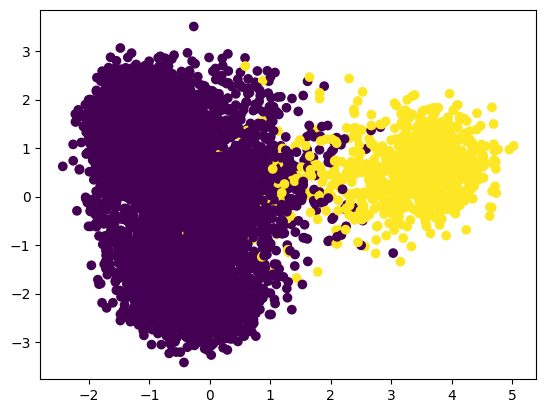

In [93]:
plt.scatter(data[:, 0], data[:, 1], c=clusters)


In [94]:
submission = pd.DataFrame({
    "subtaskID":1,
    "datapointID": test['datapointID'],
    "answer":clusters
})

In [95]:
submission.to_csv('submission_subtask1.csv', index = False)

In [96]:
news_data = data[clusters ==0]
news_data.shape

(6166, 2)

In [97]:
tsne = TSNE(n_components = 2, perplexity = 50)
visualization_data = tsne.fit_transform(news_data)

In [98]:
visualization_data.shape

(6166, 2)

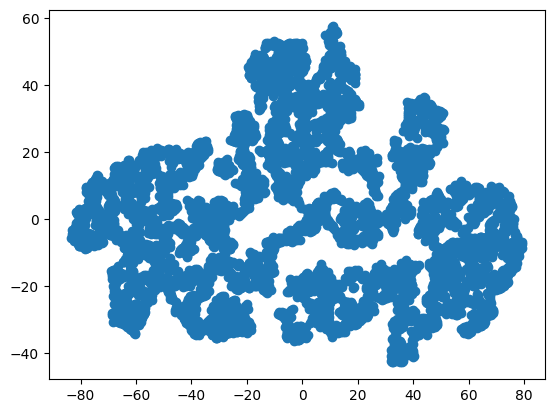

In [99]:
plt.scatter(visualization_data[:, 0], visualization_data[:, 1])

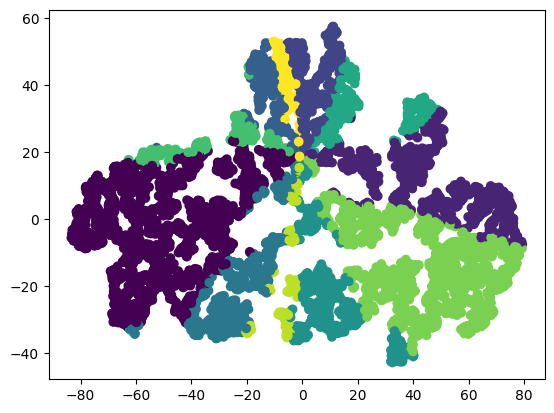

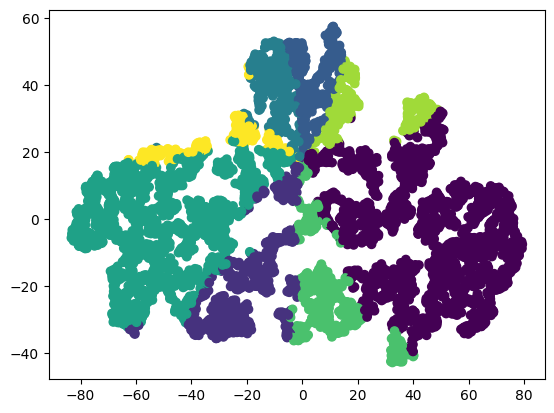

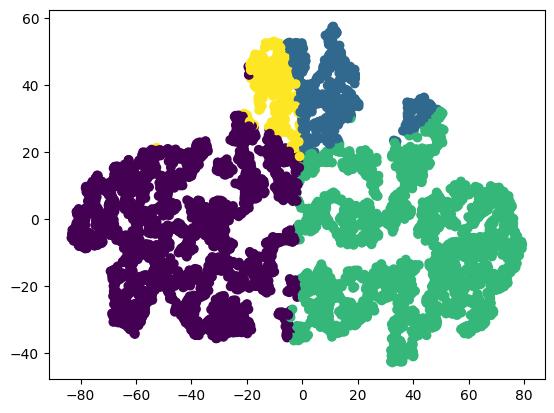

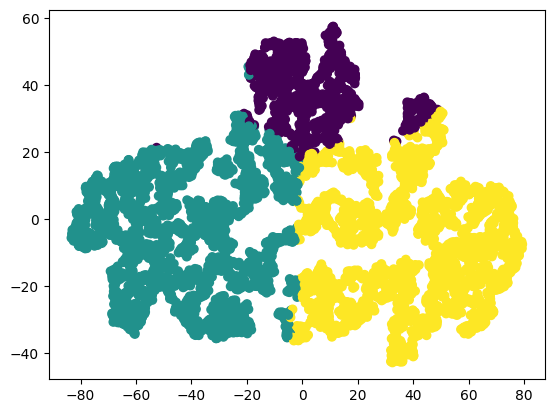

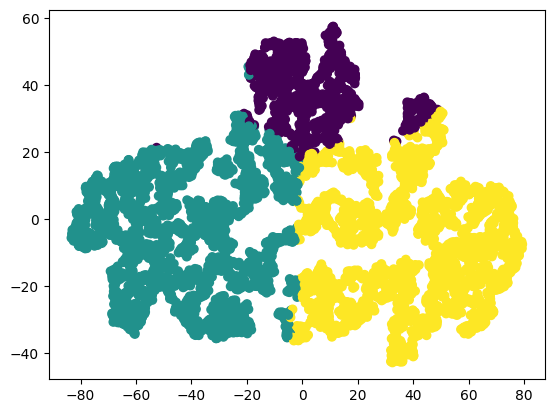

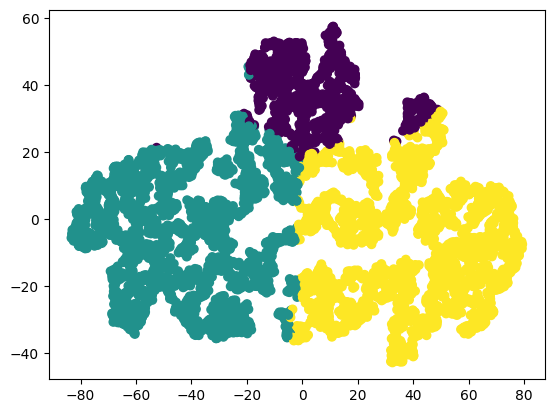

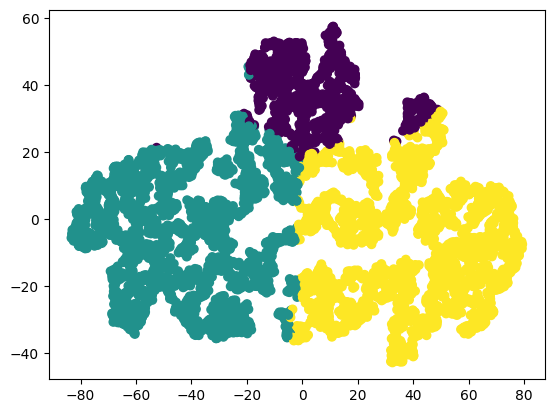

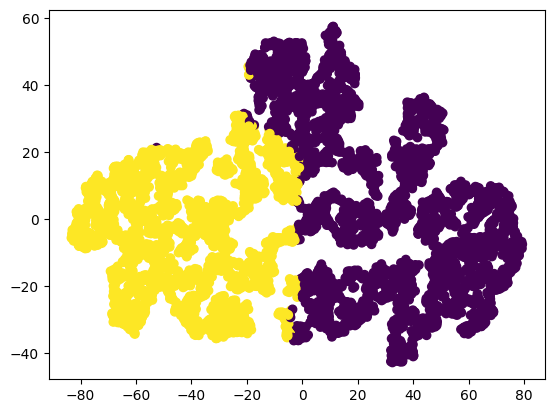

In [100]:
thresholds_clustering = [0.1, 0.2,0.4, 0.6, 0.8, 1, 1.2, 1.4]

for x in thresholds_clustering:
  clusterlash = AgglomerativeClustering(n_clusters=None, metric='cosine', linkage='average', distance_threshold=x)
  new_clusters = clusterlash.fit_predict(news_data)
  plt.scatter(visualization_data[:, 0], visualization_data[:, 1], c = new_clusters)
  plt.show()


In [149]:
from sklearn.cluster import SpectralClustering
clusterlash = KMeans(n_clusters = 3)
secondclusters = clusterlash.fit_predict(visualization_data)

In [146]:
mask_for_original_zeros = (clusters == 0)
clusters[clusters == 1] = -1
clusters[mask_for_original_zeros] = secondclusters + 1

In [147]:
secondsubmission = pd.DataFrame({
    "subtaskID":2,
    "datapointID": test['datapointID'],
    "answer":clusters
})

In [148]:
secondsubmission.to_csv('submission_subtask2.csv', index = False)

In [154]:
finalsubmission = pd.concat([submission, secondsubmission])
finalsubmission

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,1
3,1,3,0
4,1,4,0
...,...,...,...
6995,2,6995,2
6996,2,6996,2
6997,2,6997,1
6998,2,6998,1


In [155]:
finalsubmission.to_csv("final_submission.csv", index = False)